Nom : 

Prénom :

# Examen de TP d'Informatique Quantique - Consignes

Le TP est calibré pour durer 1h30 (+ 30 minutes pour les tiers-temps). Les exercices sont tous indépendants et proposés en ordre croissant de difficulté. A la fin des 1h30, vous avez 10 minutes pour m'envoyer votre notebook par mail, renommé avec votre nom.

L'examen se fait seul, aucune collaboration n'est autorisée. Vous avez cependant le droit d'utiliser vos anciens TP ainsi qu'internet. L'IA est très peu recommandée pour ce genre de sujet, et si vous décidez de l'utiliser, faites le intelligemment.

**Code à lancer pour que le TP fonctionne**


In [1]:
# Exécuter seulement dans Google Colab
!pip install myqlm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.2/833.2 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.8/90.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 648.5/648.5 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.0/661.0 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 58.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 75.3 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.6/285.6 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 911.0/911.0 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 67.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.5/742.5 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.9 MB

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from qat.lang import QRoutine, H, CNOT, RY, Z, X, CCNOT, Program
from qat.synthopline.linear_synthesis import extract_linear_operator
from qat.qpus import get_default_qpu

qpu = get_default_qpu()

def display_result(circuit, nbshots=0, idx=None):
    result = qpu.submit(circuit.to_job(nbshots=nbshots, qubits=idx))
    if nbshots:
        tmp = {}
        for sample in result:
            state = sample.state
            if not state in tmp:
                tmp[state] = 0.
            tmp[sample.state] += sample.probability
        for state, proba in tmp.items():
            print("Etat %s: probabilité %s" % (state, proba))
    else:
        for sample in result:
            print("Etat %s: probabilité %s, amplitude %s" % (sample.state, sample.probability, sample.amplitude))

def circuit_to_map(circuit):
    n = circuit.arity
    N = 1 << n
    coords = []
    for i in range(N):
        rout = QRoutine()
        qreg = rout.new_wires(n)
        for j in range(n):
            if i & (1 << j):
                X(qreg[j])
        circuit(qreg)
        result = qpu.submit(rout.to_job())
        for sample in result:
            if sample.amplitude != 0:
                coords.append((i, sample.state.int))

    # Lis l'image du plan vierge
    img = mpimg.imread("img/plan.png")
    # Crée le plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=[0, 16, 0, 16])

    # Dessiner les croix
    for (x, y) in coords:
        ax.scatter(x + 0.5, 15 - y + 0.5, 
                marker='x', 
                color="#E67E22", 
                s=200,
                linewidth=3)

    ax.set_xticks(range(17))
    ax.set_yticks(range(17))
    ax.set_title("Plan du Louvre")
    plt.gca().invert_yaxis()

    plt.show()

def plot_states(circuit):
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    axes_flat = axes.flatten()
    for i in range(4):
        ax = axes_flat[i]
        rout = QRoutine()
        q = rout.new_wires(4)
        for j in range(2):
            if i & (1<<j):
                X(q[j])
        circuit(q)
        result = qpu.submit(rout.to_job())
        amplitude = np.zeros((16))
        for sample in result:
            amplitude[sample.state.int] = sample.probability
        ax.bar(range(16), amplitude, width=0.4, color="#95A5A6")
        ax.set_ylim(0, 0.7)
    plt.show()

    


# Sujet : Opération "Voler les bijoux de la Couronne"


<table>
  <tr>
    <td width="20%">
        <img src="img/jerry.jpg" width="100%">
    </td>
    <td width="80%">
    <h3>Briefing de Jerry</h3>
    Bonjour, nous avons une situation de la plus haute importance. Le budget du WOOHP a subi quelques coupes sombres récemment, et il est temps de récupérer un petit retour sur investissements. Notre cible : le Louvre. La mission est simple : "Voler les bijoux de la couronne".
    <center>
    <img src="img/bijoux.jpg" width="400">
    </center>
    Le musée est protégé par un système de sécurité quantique dernier cri. Si vous essayez de forcer les verrous de manière classique, vous déclencherez une alarme avant même d'avoir franchi le premier couloir. Gladys a modifié vos terminaux pour qu'ils puissent s'interfacer avec le processeur quantique central du Louvre.

Voici le déroulé de la mission :
1) Repérer sur le plan les bijoux à voler et les systèmes de sécurité physiques au sein du musée.
2) S'infiltrer par la porte sécurisée
3) Voler les bijoux en 7 minutes chrono
    </td>
  </tr>
</table>



## Exercice 1 : Etude du plan du musée (4 points / 20)

Comme le Louvre est un musée très sécurisé, toutes les informations dont nous avons besoin pour mettre en place le plan sont encodées. L'encodage choisi est un peu particulier, ce sont des circuits quantiques. Par chance, nous avons en notre possession un code qui permet de décoder ces circuits quantiques et obtenir l'information cachée.


Tout d'abord, il faut localiser les cibles à voler. Nous disposons du plan vierge du musée

![Plan](img/plan.png)

Nous avons obtenus en amont la localisation des bijoux et joyaux de la Couronne de France, mais celles-ci sont encodées via le circuit quantique suivant

![Circuit localisation](img/circuit_2.png)

**Question 1** Implémenter le circuit quantique ci-dessus à l'aide d'une routine quantique. Pour afficher l'emplacement des différents objets à voler (il y en à 16 au total), utiliser la fonction *circuit_to_map(circuit)*.

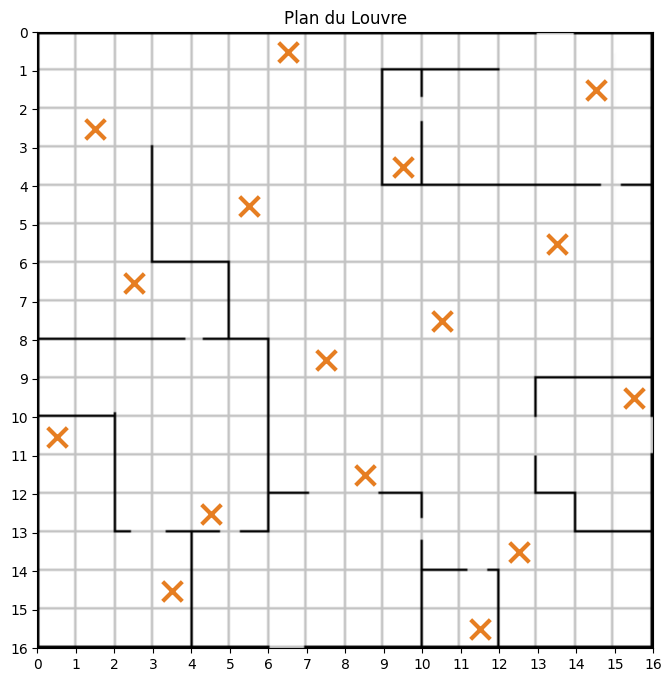

In [8]:
def emplacement():
  rout = QRoutine()
  q = rout.new_wires(4)
  
  CNOT(q[2], q[0])
  X(q[3])
  
  X(q[0])
  X(q[1])
  
  CNOT(q[0], q[1])
  CNOT(q[2], q[1])
  
  CNOT(q[0], q[1])
  
  CNOT(q[1], q[0])
  
  return rout

emplacement().display()
circuit_to_map(emplacement())

Malheureusement, grand musée implique gros système de surveillance. Par chance, nous avons accès à la carte de l'installation de ces systèmes via le circuit quantique suivant

![Circuit sécurité](img/circuit_1.png)

**Question 2** Implémenter le circuit quantique ci-dessus à l'aide d'une routine quantique. Pour afficher la localisation des différents systèmes de sécurité, utiliser la fonction *circuit_to_map(circuit)*.

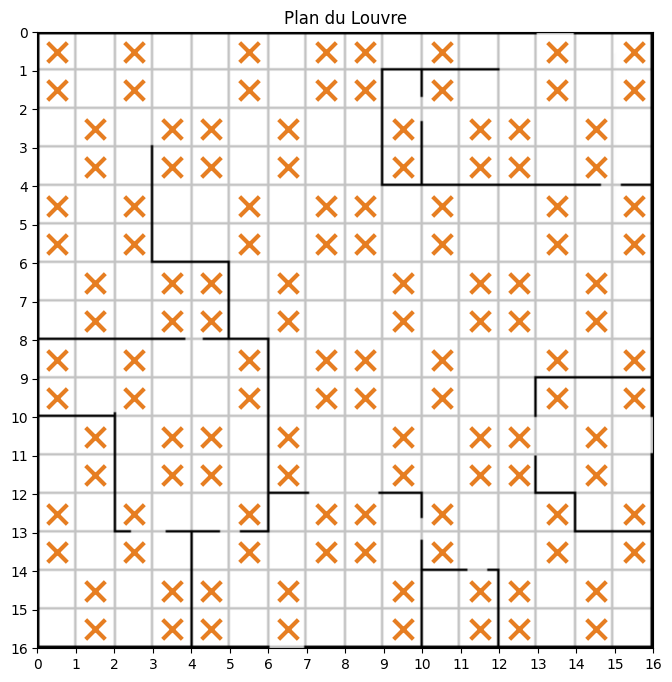

In [9]:
def security():
  rout = QRoutine()
  q = rout.new_wires(4)
  
  X(q[0])
  H(q[3])
  
  CNOT(q[0], q[2])
  X(q[3])
  
  H(q[0])
  H(q[1])
  
  X.ctrl(3)(q[0], q[1], q[2], q[3])
  
  return rout

security().display()
circuit_to_map(security())

Les systèmes de sécurité présents dans le musée sont trop complexes pour que nous puissons les contourner, nous devons donc nous restreindre aux objets n'étant pas directement surveillés.

**Question 3** En regroupant les informations des questions 1 et 2, combien d'objets allons nous pouvoir dérober ?

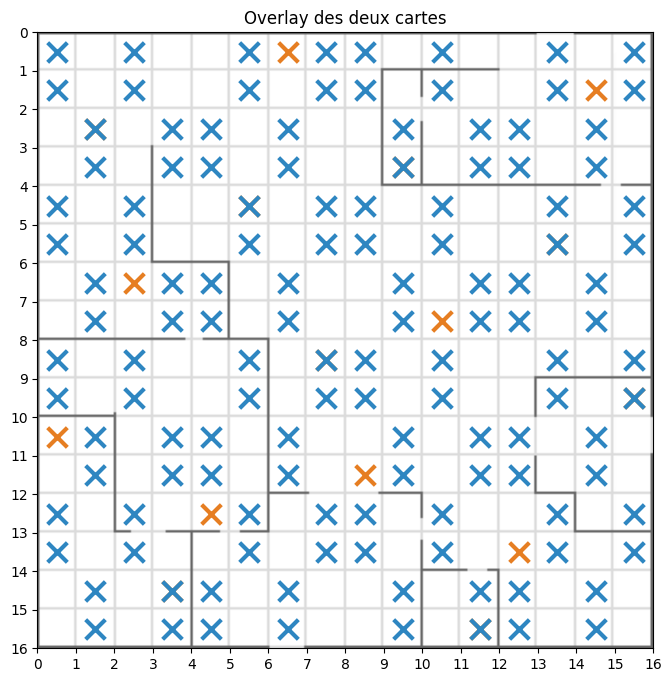

Nombre d'objets dérobables : 8


In [10]:
# Overlay des deux cartes en réutilisant la logique de circuit_to_map
def _circuit_coords(circuit):
    n = circuit.arity
    N = 1 << n
    coords = []
    for i in range(N):
        rout = QRoutine()
        qreg = rout.new_wires(n)
        for j in range(n):
            if i & (1 << j):
                X(qreg[j])
        circuit(qreg)
        result = qpu.submit(rout.to_job())
        for sample in result:
            if sample.amplitude != 0:
                coords.append((i, sample.state.int))
    return coords

def circuit_to_map(circuit, ax=None, show=True, color="#E67E22", alpha=1.0, title="Plan du Louvre"):
    coords = _circuit_coords(circuit)

    img = mpimg.imread("img/plan.png")
    own_fig = False
    if ax is None:
        own_fig = True
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig = ax.figure

    ax.imshow(img, extent=[0, 16, 0, 16], alpha=alpha)
    for (x, y) in coords:
        ax.scatter(
            x + 0.5,
            15 - y + 0.5,
            marker='x',
            color=color,
            s=200,
            linewidth=3
        )

    ax.set_xticks(range(17))
    ax.set_yticks(range(17))
    ax.set_title(title)
    ax.invert_yaxis()

    if show and own_fig:
        plt.show()

    return coords

def overlay_circuit_maps(circuit_1, circuit_2):
    fig, ax = plt.subplots(figsize=(8, 8))

    coords_1 = circuit_to_map(
        circuit_1,
        ax=ax,
        show=False,
        color="#E67E22",
        alpha=0.6,
        title="Overlay des deux cartes"
    )
    coords_2 = circuit_to_map(
        circuit_2,
        ax=ax,
        show=False,
        color="#2E86C1",
        alpha=0.0,
        title="Overlay des deux cartes"
    )

    plt.show()

    # Objets non surveillés = objets présents dans la carte emplacement
    # mais absents de la carte security
    non_surveille = sorted(set(coords_1) - set(coords_2))
    print("Nombre d'objets dérobables :", len(non_surveille))
    return non_surveille

objets_derobables = overlay_circuit_maps(emplacement(), security())

## Exercice 2 : Passer la porte d'entrée sécurisée (7 points / 20)

Si le Louvres était un petit musée de quartier, on pourrait imaginer passer par une fenêtre pour rentrer, mais ce n'est pas le cas. Nous devons rentrer par la porte sécurisée. Elle demande de résoudre une tâche très complexe pour un cambrioleur : une addition **AVEC** retenue. Comme vous n'avez pas pensé à prendre votre calculatrice, plus qu'une seule solution s'offre à vous : utiliser l'ordinateur quantique pour résoudre ce problème. Considérons deux entiers encodés sur 3 bits

$$
    a = a_2a_1a_0 \textrm{ et } b = b_2b_1b_0
$$

Nous souhaitons calculer la somme exacte de ces deux entiers et stocker cette valeur, qui sera encodée sur 4 bits pour prendre en considération la retenue. Pour ce faire, nous allons avoir besoin de deux opérateurs, que nous allons nommer $O_1$ et $O_2$ par manque d'originalité.

### Opérateur $O_1$
L'opérateur $O_1$ est un opérateur sur 3 qubits ayant pour circuit quantique

![Circuit O1](img/circuit_O1.png)

**Question 1** Implémenter l'opérateur O1 correspondant au circuit quantique ci-dessus

In [11]:
def O1():
    rout = QRoutine()
    q = rout.new_wires(3)
    
    CNOT(q[2], q[1])
    CNOT(q[2], q[0])
    CCNOT(q[0], q[1], q[2])
    
    return rout
O1().display()

Supposons que le système en entrée de $O_1$ soit $|q_0\rangle|q_1\rangle|q_2\rangle$

**Question 2** Expliciter l'état en sortie à la main (en utilisant les opérateurs binaires tels que le ou exclusif "^")

En notant l'entrée $|q_0\rangle|q_1\rangle|q_2\rangle$, l'opérateur $O_1$ applique successivement :

- $q_1 \leftarrow q_1 \oplus q_2$
- $q_0 \leftarrow q_0 \oplus q_2$
- $q_2 \leftarrow q_2 \oplus \big((q_0 \oplus q_2)(q_1 \oplus q_2)\big)$

Donc l'état de sortie est :

$$
|q_0 \oplus q_2\rangle\,|q_1 \oplus q_2\rangle\,\left|q_2 \oplus \big((q_0 \oplus q_2)(q_1 \oplus q_2)\big)\right\rangle.
$$

On peut aussi écrire le dernier bit comme la retenue (majorité) :
$$
q_2' = q_0q_1 \oplus q_0q_2 \oplus q_1q_2.
$$

Vérifier numériquement en affichant chaque entrée possible sur les 3 qubits $|q_0\rangle|q_1\rangle|q_2\rangle$. Vous pouvez utiliser la fonction *display_result(circuit)*.

In [17]:
n = 2
N = 1 << n
rout = QRoutine()
qubits = rout.new_wires(n + 1)

for i in range(N):
    # initialisation de x
    for j in range(n):
        if i & (1 << j):
            X(qubits[j])

    O1()(qubits)
    display_result(rout)

Etat |000>: probabilité 1.0, amplitude (1+0j)
Etat |100>: probabilité 1.0, amplitude (1+0j)
Etat |111>: probabilité 1.0, amplitude (1+0j)
Etat |110>: probabilité 1.0, amplitude (1+0j)


### Opérateur $O_2$

L'opérateur $O_2$ est décrit par le circuit suivant

![Circuit O2](img/circuit_O2.png)

**Question 3** Implémenter la routine quantique qui décrit le circuit $O_2$


In [18]:
def O2():
    rout = QRoutine()
    q = rout.new_wires(3)
    
    CCNOT(q[0], q[1], q[2])
    CNOT(q[2], q[0])
    CNOT(q[0], q[1])
    
    return rout
O2().display()

### Additionneur

Maintenant, grâce à nos deux opérateur $O_1$ et $O_2$, nous sommes en mesure de faire une addition. Il suffit de faire une combinaison astucieuse de ces deux opératuers pour obtenir le résultat. Toujours avec nos entiers $a=a_2a_1a_0$ et $b=b_2b_1b_0$, nous allons considérer un vecteur $c$ tel que 
- $c_0 = 0$, car on commence toujours un calcul sans retenue,
- $c_{i+1} = a_i \oplus b_i \oplus c_i$, où $\oplus$ représente l'opérateur "ou exclusif".

**Question 4** Vérifier sur toutes les entrées possibles sur 3 qubits, qu'en sorti de ce circuit $c_i$ et $a_i$ restent inchangés

![circuit 0102](img/circuit_O1O2.png)

In [19]:
def O1O2_block():
    rout = QRoutine()
    q = rout.new_wires(3)  # [a_i, b_i, c_i]
    O1()(q)
    O2()(q)
    return rout

# Vérification exhaustive sur les 8 entrées
for x in range(8):
    rout = QRoutine()
    q = rout.new_wires(3)

    for j in range(3):
        if x & (1 << j):
            X(q[j])

    O1O2_block()(q)

    result = qpu.submit(rout.to_job())
    for sample in result:
        if sample.probability > 0:
            out = sample.state.int
            a_in = (x >> 0) & 1
            b_in = (x >> 1) & 1
            c_in = (x >> 2) & 1

            a_out = (out >> 0) & 1
            b_out = (out >> 1) & 1
            c_out = (out >> 2) & 1

            print(
                f"entrée (a,b,c)=({a_in},{b_in},{c_in}) -> sortie ({a_out},{b_out},{c_out})"
            )

entrée (a,b,c)=(0,0,0) -> sortie (0,0,0)
entrée (a,b,c)=(1,0,0) -> sortie (0,1,1)
entrée (a,b,c)=(0,1,0) -> sortie (0,1,0)
entrée (a,b,c)=(1,1,0) -> sortie (0,0,1)
entrée (a,b,c)=(0,0,1) -> sortie (1,1,0)
entrée (a,b,c)=(1,0,1) -> sortie (1,0,1)
entrée (a,b,c)=(0,1,1) -> sortie (1,0,0)
entrée (a,b,c)=(1,1,1) -> sortie (1,1,1)


Que vaut le qubit $b_i$ en sortie ?

Après le bloc $O_1$ puis $O_2$, on obtient :

- $a_i$ inchangé,
- $c_i$ inchangé,
- et le qubit $b_i$ devient
$$
b_i' = a_i \oplus b_i \oplus c_i.
$$

Donc $b_i$ contient le **bit de somme** (avec retenue d'entrée $c_i$).

Maintenant que nous avons ce petit bloc de calcul, nous pouvons construire l'additioneur au complet pour des entiers sur 3 qubits. Voici le circuit quantique correspondant

![circuit adder](img/circuit_adder.png)

**Question 5** Implémenter le circuit de l'additionneur donné ci-dessus

In [20]:
def full_adder_step(rout, a, b, cin, cout):
    # cout = a.b + cin.(a xor b) = majorité(a,b,cin)
    CCNOT(a, b, cout)
    CNOT(a, b)
    CCNOT(cin, b, cout)
    # b = a xor b xor cin (bit de somme)
    CNOT(cin, b)


def adder_3bits_circuit(a_val, b_val):
    """
    Qubits:
    0,1,2 -> a0,a1,a2
    3,4,5 -> b0,b1,b2 (deviennent les bits de somme s0,s1,s2)
    6,7,8,9 -> c0,c1,c2,c3 (retenues), avec c0=0 au départ
    """
    rout = QRoutine()
    q = rout.new_wires(10)

    # Initialisation de a et b
    for i in range(3):
        if a_val & (1 << i):
            X(q[i])
        if b_val & (1 << i):
            X(q[3 + i])

    # Ripple-carry adder
    full_adder_step(rout, q[0], q[3], q[6], q[7])  # bit 0
    full_adder_step(rout, q[1], q[4], q[7], q[8])  # bit 1
    full_adder_step(rout, q[2], q[5], q[8], q[9])  # bit 2

    return rout

# Affichage d'un circuit exemple
adder_3bits_circuit(2, 4).display()

C'est le moment fatidique de savoir si votre additionneur fonctionne, et ne déclenche pas l'alarme. Sur l'écran de la porte s'affiche une série de calculs

**Question 6** Combien font $2+4$ (avec l'ordinateur quantique) ? Vous pouvez sélectionner que les qubits intéressant dans *display_result(circuit, idx=[liste des indices])*

In [23]:
# Test 2 + 4
a_test, b_test = 2, 4
rout_2_4 = adder_3bits_circuit(a_test, b_test)

# Affichage des qubits de sortie (ordre visuel: c3,s2,s1,s0)
display_result(rout_2_4, idx=[9, 5, 4, 3])

print("Résultat (décimal) :", a_test + b_test)

Etat |0110>: probabilité 1.0, amplitude None
Résultat (décimal) : 6


Combien font $5 + 7$ (idem)

In [24]:
# Test 5 + 7
a_test, b_test = 5, 7
rout_5_7 = adder_3bits_circuit(a_test, b_test)

display_result(rout_5_7, idx=[9, 5, 4, 3])

print("Résultat (décimal) :", a_test + b_test)

Etat |1100>: probabilité 1.0, amplitude None
Résultat (décimal) : 12


## Exercice 3 : Voler les bijoux (9 points / 20)

C'est bon vous avez réussi à vous infiltrer dans le Louvre, mais vous n'avez que 7 minutes pour voler les bijoux de la Couronne. Cela peut paraître court, mais nous avons trouvé un moyen de déverouiller les vitrines où ils sont exposés simultanément. Dans le musée ultra sécurisé, il y a 4 systèmes de verrou différents $i$, chacun s'ouvrant après l'application d'une unitaire $U_i$ avec une amplitude $\alpha_i$. Si nous arrivons à appliquer simultanément toutes ces unitaires alors nous pourrons nous emparer du butin en un rien de temps. 

### Création de la superposition des $\alpha_i$
Dans un premier temps, vous allez devoir créer la superposition des amplitudes. Je vous les transmet ci dessous.

In [25]:
alphas = np.array([0.1, 0.4, 0.7, 0.2])
alphas /= np.linalg.norm(alphas)
print(alphas)

[0.11952286 0.47809144 0.83666003 0.23904572]


Vous allez devoir encoder ces différentes amplitudes dans les amplitudes d'un registre quantique à 2 qubits $|\psi\rangle$ tel que

$$
|\psi\rangle = \alpha_0 |0\rangle_{a_0}|0\rangle_{a_1} + \alpha_1 |1\rangle_{a_0}|0\rangle_{a_1} + \alpha_2 |0\rangle_{a_0}|1\rangle_{a_1} + \alpha_3 |1\rangle_{a_0}|1\rangle_{a_1}.
$$

Pour ce faire, nous allons utiliser des rotations $RY(\theta)$. Pour rappel, la porte $RY(\theta)$ fonctionne de la manière suivante lorsqu'appliquée à l'état $|0\rangle$
$$
RY(\theta)|0\rangle = \cos(\theta / 2) |0\rangle + \sin(\theta / 2) |1\rangle
$$

Nous devons donc déterminer en amont 3 probabilités différentes, desquelles découleront des angles de rotation pour nos RY

1) $p_1$ qui est la probabilité sur le premier qubit $a_0$ à 0
2) $p_2$ qui est la probabilité sur le deuxième qubit $a_1$ à 0, sachant que le premier est à 0
3) $p_3$ qui est la probabilité sur le deuxième qubit $a_1$ à 0, sachant que le premier est à 1

**Question 1** Trouver ces probabilités à partir des amplitudes données par le vecteur *alphas*


In [26]:
# Probabilités à partir des amplitudes
# Convention : alpha_0 -> |a0=0,a1=0>, alpha_1 -> |1,0>, alpha_2 -> |0,1>, alpha_3 -> |1,1>

p1 = np.abs(alphas[0])**2 + np.abs(alphas[2])**2
p2 = np.abs(alphas[0])**2 / p1
p3 = np.abs(alphas[1])**2 / (1 - p1)

print(f"p1 = {p1:.6f}")
print(f"p2 = {p2:.6f}")
print(f"p3 = {p3:.6f}")

p1 = 0.714286
p2 = 0.020000
p3 = 0.800000


Maintenant, il faut passer des probabilités aux angles de rotation pour les RY associées, en utilisant notamment la fonction arccos.

**Question 2** Exprimer les angles $\theta_1$, $\theta_2$ et $\theta_3$ tels que $RY(\theta_i) |0\rangle = \sqrt{p_i} |0\rangle + \dots$

In [27]:
# Pour RY(theta)|0> = cos(theta/2)|0> + sin(theta/2)|1>
# on impose cos(theta_i/2) = sqrt(p_i)

theta_1 = 2 * np.arccos(np.sqrt(p1))
theta_2 = 2 * np.arccos(np.sqrt(p2))
theta_3 = 2 * np.arccos(np.sqrt(p3))

print(f"theta_1 = {theta_1:.6f} rad")
print(f"theta_2 = {theta_2:.6f} rad")
print(f"theta_3 = {theta_3:.6f} rad")

theta_1 = 1.127885 rad
theta_2 = 2.857799 rad
theta_3 = 0.927295 rad


**Question 3** Construire le circuit quantique qui :
1) Crée la superposition $\sqrt{p_1} |0\rangle + \sqrt{1-p_1}|1\rangle$ sur le qubit $a_0$
2) Crée la superposition $\sqrt{p_2} |0\rangle + \sqrt{1-p_2}|1\rangle$ sur le qubit $a_1$, contrôlée par le qubit $a_0$ à $0$ (en utilisant une RY contrôlée encadrée de 2 portes X)
3) Crée la superposition $\sqrt{p_3} |0\rangle + \sqrt{1-p_3}|1\rangle$ sur le qubit $a_1$, contrôlée par le qubit $a_0$ à $1$ (en utilisant une RY contrôlée)

In [28]:
def prepare_alpha_state(theta1, theta2, theta3):
    rout = QRoutine()
    a = rout.new_wires(2)  # a[0]=a0, a[1]=a1

    # 1) superposition sur a0
    RY(theta1)(a[0])

    # 2) superposition sur a1 contrôlée par a0=0
    X(a[0])
    RY(theta2).ctrl()(a[0], a[1])
    X(a[0])

    # 3) superposition sur a1 contrôlée par a0=1
    RY(theta3).ctrl()(a[0], a[1])

    return rout

prepare_alpha_state(theta_1, theta_2, theta_3).display()

On peut alors vérifier que la bonne superposition des amplitudes est créée en appelant *display_result* sur ce circuit

In [29]:
display_result(prepare_alpha_state(theta_1, theta_2, theta_3))

Etat |00>: probabilité 0.014285714285714271, amplitude (0.1195228609334393+0j)
Etat |01>: probabilité 0.6999999999999998, amplitude (0.8366600265340755+0j)
Etat |10>: probabilité 0.22857142857142862, amplitude (0.4780914437337575+0j)
Etat |11>: probabilité 0.05714285714285738, amplitude (0.23904572186687922+0j)


### Création des unitaires $U_i$

Maintenant que vous avez la superposition des $\alpha_i$, occupons nous des 4 unitaires $U_i$. Ce sont des unitaires agissant sur 2 qubits et décrites chacune par un circuit quantique en particulier.

1) $U_0$ : opérateur identité $\rightarrow$ Circuit sans porte quantique
2) $U_1$ donné en image ci-dessous
3) $U_2$ donné en image ci-dessous
4) $U_4$ : circuit permettant de réaliser une paire de Bell (description donnée ci-dessous)

Le circuit de $U_0$ étant trivial, son implémentation est déjà donnée.

In [ ]:
def U_0():
    rout = QRoutine()
    qreg = rout.new_wires(2)

    return rout

#### Circuit $U_1$

Voici le circuit correspondant à l'unitaire $U_1$

![circuit U1](img/ex3_circuit2.png)

**Question 4** Implémenter le circuit correspondant

In [30]:
def U_1():
    rout = QRoutine()
    qreg = rout.new_wires(2)

    H(qreg[0])
    CNOT(qreg[0], qreg[1])

    return rout

U_1().display()

#### Circuit $U_2$

Voici le circuit correspondant à l'unitaire $U_2$
![U2](img/ex3_circuit3.png)

**Question 5** Implémenter le circuit correspondant

In [31]:
def U_2():
    rout = QRoutine()
    qreg = rout.new_wires(2)

    X(qreg[0])
    CNOT(qreg[0], qreg[1])
    H(qreg[1])

    return rout

U_2().display()

#### Circuit $U_3$

Le dernier circuit n'est pas donné directement mais nous avons obtenu l'information qu'il permet de créer une paire de Bell suivant l'opération suivante :

$$
U_3 |0\rangle_{q_0}|0\rangle_{q_1} = \frac{1}{\sqrt{2}} (|0\rangle_{q_0}|1\rangle_{q_1} + |1\rangle_{q_0}|0\rangle_{q_1})
$$

**Question 6** Implémenter le circuit quantique correspondant à cette opération

In [32]:
def U_3():
    rout = QRoutine()
    qreg = rout.new_wires(2)

    # |00> -> (|01> + |10>)/sqrt(2)
    X(qreg[1])
    H(qreg[0])
    CNOT(qreg[0], qreg[1])
    X(qreg[1])

    return rout

U_3().display()

### Combinaison des unitaires

Maintenant, il ne reste plus qu'à tout combiner ensemble. L'objectif est de créer l'unitaire suivante

$$
\sum_i \alpha_i U_i,
$$

qui représente donc la superposition des unitaires $U_i$ que nous avons pu implémenter juste avant, suivant la distribution de probabilité donnée par le vecteur contenant les $\alpha_i$.

L'algorithme de combinaison se décompose en 3 étapes et utilise 4 qubits : 2 qubits de donnée $q_0$ et $q_1$ sur lesquels nous allons appliquer nos opérateurs $U_i$ et 2 qubits ancillaires de travail $a_0$ et $a_1$ qui vont servir à créer la superposition des unitaires. Voici les étapes à suivre :
1) Préparer la superposition $|\psi\rangle = \alpha_0 |0\rangle_{a_0}|0\rangle_{a_1} + \alpha_1 |1\rangle_{a_0}|0\rangle_{a_1} + \alpha_2 |0\rangle_{a_0}|1\rangle_{a_1} + \alpha_3 |1\rangle_{a_0}|1\rangle_{a_1}$.
2) Appliquer les différentes unitaires $U_i$ sur les qubits $q_0$ et $q_1$, en les controllant par les qubits ancillaires $a_0a_1$ dans l'état $|i\rangle$
3) Défaire la superposition d'état sur les qubits $a_0$ et $a_1$

Pour simplifier le travail, une représentation sous forme de circuit est donnée ci-dessous

![LCU](img/lcu.png)

**Question 7** Implémenter ce circuit quantique

In [33]:
def _prepare_alpha_on_wires(a0, a1, inverse=False):
    if not inverse:
        RY(theta_1)(a0)
        X(a0)
        RY(theta_2).ctrl()(a0, a1)
        X(a0)
        RY(theta_3).ctrl()(a0, a1)
    else:
        # Inverse exact de la préparation (ordre inverse, angles opposés)
        RY(-theta_3).ctrl()(a0, a1)
        X(a0)
        RY(-theta_2).ctrl()(a0, a1)
        X(a0)
        RY(-theta_1)(a0)


def _apply_u1_controlled_on_state(a0, a1, q0, q1, s0, s1):
    if s0 == 0:
        X(a0)
    if s1 == 0:
        X(a1)

    H.ctrl(2)(a0, a1, q0)
    CNOT.ctrl(2)(a0, a1, q0, q1)

    if s1 == 0:
        X(a1)
    if s0 == 0:
        X(a0)


def _apply_u2_controlled_on_state(a0, a1, q0, q1, s0, s1):
    if s0 == 0:
        X(a0)
    if s1 == 0:
        X(a1)

    X.ctrl(2)(a0, a1, q0)
    CNOT.ctrl(2)(a0, a1, q0, q1)
    H.ctrl(2)(a0, a1, q1)

    if s1 == 0:
        X(a1)
    if s0 == 0:
        X(a0)


def _apply_u3_controlled_on_state(a0, a1, q0, q1, s0, s1):
    if s0 == 0:
        X(a0)
    if s1 == 0:
        X(a1)

    X.ctrl(2)(a0, a1, q1)
    H.ctrl(2)(a0, a1, q0)
    CNOT.ctrl(2)(a0, a1, q0, q1)
    X.ctrl(2)(a0, a1, q1)

    if s1 == 0:
        X(a1)
    if s0 == 0:
        X(a0)


def lcu_circuit():
    rout = QRoutine()
    q = rout.new_wires(4)

    # Qubits de donnée
    q0, q1 = q[0], q[1]
    # Qubits ancillaires
    a0, a1 = q[2], q[3]

    # 1) Préparer |psi> = sum_i alpha_i |i> sur les ancillas
    _prepare_alpha_on_wires(a0, a1, inverse=False)

    # 2) Appliquer les U_i contrôlées par |a0 a1> = |i>
    # i=0 : U_0 = identité (rien à faire)
    _apply_u1_controlled_on_state(a0, a1, q0, q1, 1, 0)  # i=1
    _apply_u2_controlled_on_state(a0, a1, q0, q1, 0, 1)  # i=2
    _apply_u3_controlled_on_state(a0, a1, q0, q1, 1, 1)  # i=3

    # 3) Défaire la superposition ancillaire
    _prepare_alpha_on_wires(a0, a1, inverse=True)

    return rout

lcu_circuit().display()

Utilisez la fonction *plot_states(circuit)* pour afficher la réponse du système à votre circuit.

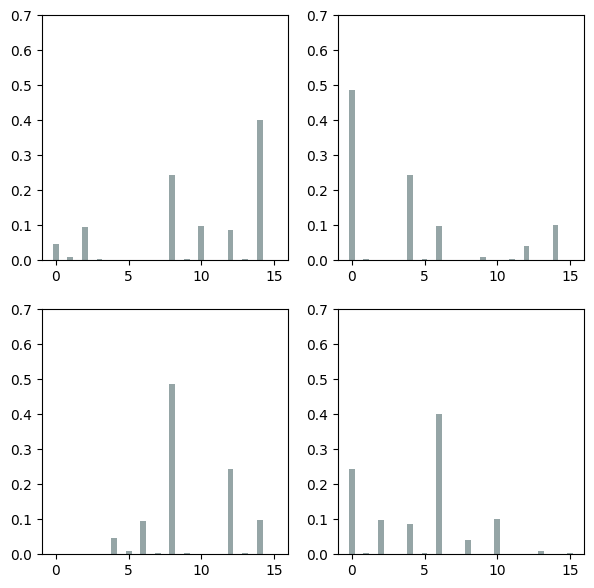

In [34]:
plot_states(lcu_circuit())

Voici la réponse que nous sommes censés obtenir pour les 4 types d'entrée différentes possibles. 

![Final output](img/final_outpu.png)